# Étape 5 — Graphe de compétences et communautés internes des CV

Ce notebook construit un graphe global pondéré de cooccurrence des compétences présentes dans les
CV, détecte des communautés de compétences, puis projette ces communautés sur chaque CV. Il produit
des **features descriptives** de concentration et de diversité, sans définir de classe
« spécialisé/polyvalent » et sans effectuer de classification ou de prédiction de liens.

## 1. Chargement des CV et contrôles rapides

Seule la table des CV est nécessaire. Nous reprenons exactement le chargement validé à l'Étape 1 :
le dépôt Hugging Face possède un sous-dossier `resumes` et un split `train`. Les chemins de sortie
restent relatifs, que le notebook soit lancé depuis la racine ou depuis `notebooks`.

In [1]:
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
from IPython.display import Markdown, display
import json
import math
import pickle
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from datasets import load_dataset

DATASET_ID = "michaelozon/candidate-matching-synthetic"
ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
FIGURES_DIR = ROOT / "figures" / "step5"
RESULTS_DIR = ROOT / "results"
PROCESSED_DIR = ROOT / "data" / "processed"
for directory in (FIGURES_DIR, RESULTS_DIR, PROCESSED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

df_resumes = load_dataset(
    DATASET_ID, data_dir="resumes", split="train"
).to_pandas()

def as_unique_list(value):
    """Convertit une cellule de skills en liste Python sans doublon interne."""
    if value is None:
        return []
    values = value.tolist() if hasattr(value, "tolist") else list(value)
    return list(dict.fromkeys(values))

resume_skill_lists = df_resumes["skills"].map(as_unique_list)
all_skills = sorted({skill for skills in resume_skill_lists for skill in skills})

print("Nombre de CV :", len(df_resumes))
print("Nombre de compétences uniques :", len(all_skills))
assert len(df_resumes) == 10_000
assert len(all_skills) == 73

Nombre de CV : 10000
Nombre de compétences uniques : 73


## 2. Choix de modélisation : un graphe global de cooccurrence

La consigne parle de « graphes de compétences internes », sans imposer une construction unique.
Nous faisons le choix méthodologique suivant :

- un **nœud** représente une compétence ;
- deux compétences sont reliées si elles apparaissent ensemble dans au moins un CV ;
- le **poids** de leur arête est le nombre de CV dans lesquels elles apparaissent ensemble.

Ainsi, un poids élevé signifie une cooccurrence fréquente dans le dataset, et non une similarité
sémantique calculée par un modèle. Construire séparément un graphe complet pour chaque CV serait peu
informatif : toutes les compétences du CV seraient reliées de la même manière et chaque petit graphe
serait une clique. Le graphe global apprend plutôt les relations générales entre compétences ; nous
projetterons ensuite ses communautés sur chaque CV. Ce choix appartient au projet et n'est pas une
formule imposée par le cours.

## 3. Construction du graphe de cooccurrence pondéré

Pour un CV possédant $s$ compétences, `combinations(skills, 2)` produit chaque paire **non ordonnée**
exactement une fois, soit $\binom{s}{2}=s(s-1)/2$ paires. Avant cela, nous retirons seulement les
éventuels doublons internes. À chaque apparition d'une paire dans un CV, son poids est incrémenté de
1. Le poids final compte donc exactement les CV contenant simultanément les deux compétences.

In [2]:
G_skills = nx.Graph()
G_skills.add_nodes_from(all_skills)

for skills in resume_skill_lists:
    for skill_a, skill_b in combinations(sorted(skills), 2):
        if G_skills.has_edge(skill_a, skill_b):
            G_skills[skill_a][skill_b]["weight"] += 1
        else:
            G_skills.add_edge(skill_a, skill_b, weight=1)

print("Nœuds :", G_skills.number_of_nodes())
print("Arêtes :", G_skills.number_of_edges())
assert G_skills.number_of_nodes() == 73
assert all(data["weight"] > 0 for _, _, data in G_skills.edges(data=True))

Nœuds :

 73
Arêtes : 359


## 4. Structure et poids du graphe de compétences

La densité compare le nombre d'arêtes observées au maximum possible :

$$D=\frac{2m}{n(n-1)}.$$

Le degré simple compte les compétences voisines. Dans un graphe pondéré, le **strength** d'un nœud
est la somme des poids de ses arêtes : il mesure ici le volume total de cooccurrences de la
compétence. Nous décrivons aussi les poids et affichons les 20 paires les plus fréquentes avant de
prendre toute décision sur un éventuel filtrage.

,valeur
n_skill_nodes,73.000000
n_skill_edges,359.000000
density,0.136606
n_connected_components,2.000000
n_isolates,0.000000
average_degree,9.835616
average_strength,5050.958904


,valeur
min,458.0
mean,513.537604
median,512.0
max,1021.0
quantiles,"{'0.25': 497.0, '0.5': 512.0, '0.75': 527.0, '..."


,skill_a,skill_b,weight
0,KPIs,Reporting,1021
1,JavaScript,Python,562
2,JavaScript,REST APIs,561
3,OOP,Python,557
4,Python,Tableau,556
5,Git,JavaScript,555
6,JavaScript,OOP,555
7,Java,REST APIs,554
8,Python,Unit Testing,552
9,Databases,Python,551


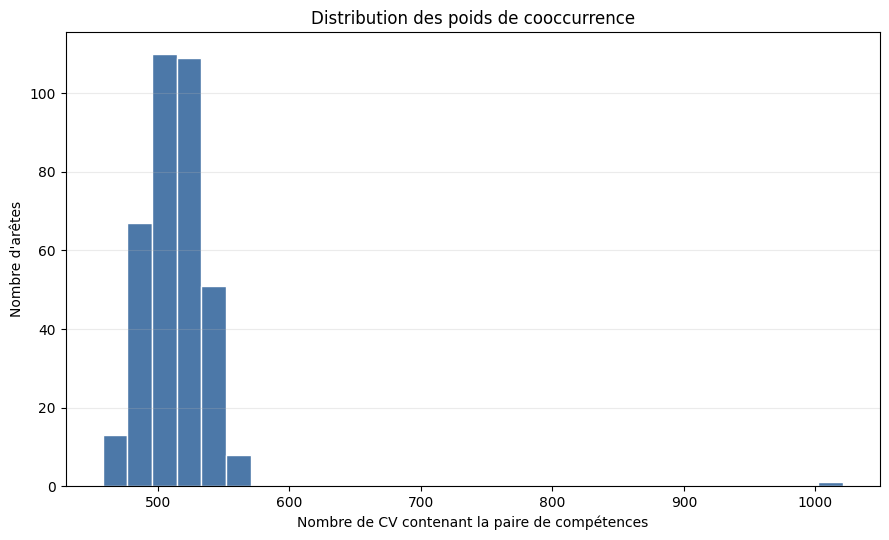

In [3]:
n_skill_nodes = G_skills.number_of_nodes()
n_skill_edges = G_skills.number_of_edges()
skill_density = nx.density(G_skills)
n_connected_components = nx.number_connected_components(G_skills)
n_isolates = nx.number_of_isolates(G_skills)
average_degree = float(np.mean([degree for _, degree in G_skills.degree()]))
average_strength = float(np.mean([strength for _, strength in G_skills.degree(weight="weight")]))

edge_weights = pd.Series(
    [data["weight"] for _, _, data in G_skills.edges(data=True)],
    name="weight",
    dtype=float,
)
weight_quantiles = edge_weights.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
weight_stats = {
    "min": float(edge_weights.min()),
    "mean": float(edge_weights.mean()),
    "median": float(edge_weights.median()),
    "max": float(edge_weights.max()),
    "quantiles": {str(q): float(value) for q, value in weight_quantiles.items()},
}

graph_stats = pd.Series({
    "n_skill_nodes": n_skill_nodes,
    "n_skill_edges": n_skill_edges,
    "density": skill_density,
    "n_connected_components": n_connected_components,
    "n_isolates": n_isolates,
    "average_degree": average_degree,
    "average_strength": average_strength,
}, name="valeur")
display(graph_stats.to_frame())
display(pd.Series(weight_stats, name="valeur").to_frame())

top_cooccurrences = pd.DataFrame(
    sorted(
        ((u, v, data["weight"]) for u, v, data in G_skills.edges(data=True)),
        key=lambda row: (-row[2], row[0], row[1]),
    )[:20],
    columns=["skill_a", "skill_b", "weight"],
)
display(top_cooccurrences)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(edge_weights, bins=30, color="#4C78A8", edgecolor="white")
ax.set(
    title="Distribution des poids de cooccurrence",
    xlabel="Nombre de CV contenant la paire de compétences",
    ylabel="Nombre d'arêtes",
)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "skill_edge_weight_distribution.png", dpi=170, bbox_inches="tight")
plt.show()

## 5. Analyse du graphe complet, sans seuil arbitraire

Un seuil choisi sans justification pourrait supprimer une partie du signal et changer les
communautés. Nous utilisons donc **toutes les arêtes et tous leurs poids** pour les calculs. La
density affichée ci-dessus permet de savoir si le graphe est presque complet ; dans ce cas, ce sera
signalé comme une propriété du dataset synthétique. Plus bas, un filtrage par quantile pourra être
appliqué uniquement à une copie destinée à la visualisation. Il ne modifiera jamais `G_skills` ni
les résultats analytiques.

In [4]:
possible_edges = n_skill_nodes * (n_skill_nodes - 1) // 2
missing_edges = possible_edges - n_skill_edges
density_message = (
    "Le graphe est presque complet : la structure dépend surtout des poids."
    if skill_density >= 0.90
    else "Le graphe n'est pas presque complet : présence/absence et poids portent du signal."
)
print(density_message)
print("Arêtes possibles :", possible_edges)
print("Arêtes absentes :", missing_edges)

Le graphe n'est pas presque complet : présence/absence et poids portent du signal.
Arêtes possibles : 2628
Arêtes absentes : 2269


## 6. Label Propagation pondéré

Le cours initialise chaque nœud avec un label unique, mélange les nœuds, puis fait adopter à chaque
nœud le label majoritaire de ses voisins. Ici, une arête de poids 200 doit compter davantage qu'une
arête de poids 2. Pour chaque label voisin, nous sommons donc les poids des arêtes qui y conduisent,
puis choisissons le label de score maximal. Les égalités sont tirées au sort avec un générateur
reproductible. Les mises à jour sont asynchrones : un label modifié peut influencer les nœuds
suivants de la même itération. L'arrêt survient lorsqu'aucun label ne change ou après `max_iter`.

Cette adaptation pondérée est un choix méthodologique naturel pour les cooccurrences ; le support
présente surtout la version non pondérée. Comme l'ordre et les égalités rendent la méthode non
déterministe, nous comparerons cinq seeds.

In [5]:
def weighted_label_propagation_manual(G, seed=42, max_iter=100, weight="weight"):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    labels = {node: index for index, node in enumerate(nodes)}

    for iteration in range(1, max_iter + 1):
        rng.shuffle(nodes)
        n_changes = 0

        for node in nodes:
            if G.degree(node) == 0:
                continue

            scores = defaultdict(float)
            for neighbor, edge_data in G[node].items():
                scores[labels[neighbor]] += float(edge_data.get(weight, 1.0))

            best_score = max(scores.values())
            best_labels = [
                label for label, score in scores.items()
                if math.isclose(score, best_score, rel_tol=1e-12, abs_tol=1e-12)
            ]
            new_label = rng.choice(best_labels)
            if new_label != labels[node]:
                labels[node] = new_label
                n_changes += 1

        if n_changes == 0:
            return labels, iteration, True

    return labels, max_iter, False


def labels_to_communities(labels):
    groups = defaultdict(set)
    for node, label in labels.items():
        groups[label].add(node)
    return list(groups.values())

## 7. Modularité pondérée et comparaison des seeds

Dans un graphe pondéré, les arêtes fortes contribuent davantage et le degré pondéré (strength)
remplace conceptuellement le degré simple. La modularité compare toujours les liaisons internes
observées à un modèle aléatoire de référence, mais avec les poids. Nous utilisons l'implémentation
fiable de NetworkX avec `weight="weight"`; la réimplémentation manuelle a déjà été validée à
l'Étape 4 pour le cas non pondéré.

Pour chaque seed, nous enregistrons la convergence, le nombre d'itérations, le nombre de
communautés, la modularité pondérée et les tailles extrêmes. La partition retenue est celle dont la
modularité est maximale parmi les cinq runs : le choix devient explicite et reproductible.

In [6]:
SEEDS = [0, 1, 2, 3, 4]
MAX_ITER = 100
run_rows = []
run_labels = {}
run_partitions = {}

for seed in SEEDS:
    labels, iterations, converged = weighted_label_propagation_manual(
        G_skills, seed=seed, max_iter=MAX_ITER, weight="weight"
    )
    communities = labels_to_communities(labels)
    modularity = nx.algorithms.community.modularity(
        G_skills, communities, weight="weight"
    )
    sizes = [len(community) for community in communities]
    run_rows.append({
        "seed": seed,
        "converged": converged,
        "iterations": iterations,
        "n_communities": len(communities),
        "weighted_modularity": float(modularity),
        "smallest_community": min(sizes),
        "largest_community": max(sizes),
    })
    run_labels[seed] = labels
    run_partitions[seed] = communities

runs_df = pd.DataFrame(run_rows).sort_values("seed").reset_index(drop=True)
display(runs_df)

best_index = runs_df["weighted_modularity"].idxmax()
best_seed = int(runs_df.loc[best_index, "seed"])
best_communities_raw = run_partitions[best_seed]
best_modularity = float(runs_df.loc[best_index, "weighted_modularity"])
print("Seed retenue :", best_seed)
print("Modularité pondérée :", best_modularity)

,seed,converged,iterations,n_communities,weighted_modularity,smallest_community,largest_community
0,0,True,3,8,0.711254,7,10
1,1,True,3,7,0.700724,8,18
2,2,True,4,7,0.700724,8,18
3,3,True,3,8,0.718392,6,10
4,4,True,3,8,0.718392,6,10


Seed retenue : 3
Modularité pondérée : 0.7183923632757252


## 8. Profils des communautés de compétences

Les labels produits par l'algorithme n'ont pas de signification métier. Nous réindexons les
communautés par taille décroissante, puis calculons pour chaque compétence son degré et son
strength. Les profils listent les compétences de chaque groupe et celles de strength maximal.
L'interprétation restera prudente et reposera uniquement sur ces listes ; aucun LLM ne nomme les
communautés automatiquement.

In [7]:
best_communities = sorted(
    best_communities_raw,
    key=lambda community: (-len(community), min(community)),
)
skill_community = {
    skill: community_id
    for community_id, community in enumerate(best_communities)
    for skill in community
}

assert set(skill_community) == set(G_skills.nodes())
assert len(skill_community) == G_skills.number_of_nodes()

skill_rows = []
for skill in sorted(G_skills.nodes()):
    skill_rows.append({
        "skill": skill,
        "skill_community": skill_community[skill],
        "degree": G_skills.degree(skill),
        "weighted_degree": float(G_skills.degree(skill, weight="weight")),
    })
skill_communities_df = pd.DataFrame(skill_rows)
skill_communities_df.to_csv(
    RESULTS_DIR / "step5_skill_communities.csv", index=False
)

community_profiles = []
for community_id, community in enumerate(best_communities):
    ranked = sorted(
        community,
        key=lambda skill: (-G_skills.degree(skill, weight="weight"), skill),
    )
    community_profiles.append({
        "community_id": community_id,
        "n_skills": len(community),
        "skills": sorted(community),
        "top_skills_by_strength": [
            {
                "skill": skill,
                "strength": float(G_skills.degree(skill, weight="weight")),
            }
            for skill in ranked[:10]
        ],
    })

(RESULTS_DIR / "step5_skill_community_profiles.json").write_text(
    json.dumps(community_profiles, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

display(skill_communities_df.sort_values(
    ["skill_community", "weighted_degree"], ascending=[True, False]
))
for profile in community_profiles:
    print(f"Communauté {profile['community_id']} ({profile['n_skills']} skills)")
    print(", ".join(profile["skills"]))
    print()

,skill,skill_community,degree,weighted_degree
0,A/B Testing,0,27,13923.0
12,Content Marketing,0,9,4821.0
35,Landing Pages,0,9,4728.0
29,Google Ads,0,9,4684.0
13,Conversion Optimization,0,9,4683.0
...,...,...,...,...
2,Accounting,7,9,4603.0
70,Valuation,7,9,4586.0
9,Cash Flow,7,9,4505.0
71,Variance Analysis,7,9,4459.0


Communauté 0 (10 skills)
A/B Testing, Content Marketing, Conversion Optimization, Copywriting, Email Marketing, Google Ads, Landing Pages, Marketing Analytics, Meta Ads, SEO

Communauté 1 (10 skills)
Account Management, CRM, Closing, Discovery Calls, Forecasting, Lead Generation, Negotiation, Outbound Outreach, Pipeline Management, Prospecting

Communauté 2 (10 skills)
Asana, Cross-functional Coordination, Jira, KPIs, Process Improvement, Project Planning, Reporting, Risk Management, Stakeholder Communication, Timeline Management

Communauté 3 (10 skills)
CI/CD, Databases, Docker, Git, Java, JavaScript, OOP, Python, REST APIs, Unit Testing

Communauté 4 (10 skills)
Communication, Customer Satisfaction, Documentation, Escalations, Intercom, Root Cause Analysis, SLA, Ticketing, Troubleshooting, Zendesk

Communauté 5 (9 skills)
Agile, Analytics, PRD, Prioritization, Product Strategy, Roadmap, Scrum, Stakeholder Management, User Research

Communauté 6 (8 skills)
Data Visualization, ETL, Ex

## 9. Visualisation des communautés de compétences

Avec seulement 73 nœuds, les compétences peuvent être affichées, mais un graphe presque complet
produirait un « paquet de cheveux » illisible. La partition et toutes les métriques restent calculées
sur le graphe complet. Pour la **figure uniquement**, nous conservons les arêtes dont le poids est au
moins égal au 90e percentile, tout en gardant les 73 nœuds. La couleur représente la communauté, la
taille le strength calculé sur le graphe complet et la largeur le poids de l'arête affichée.

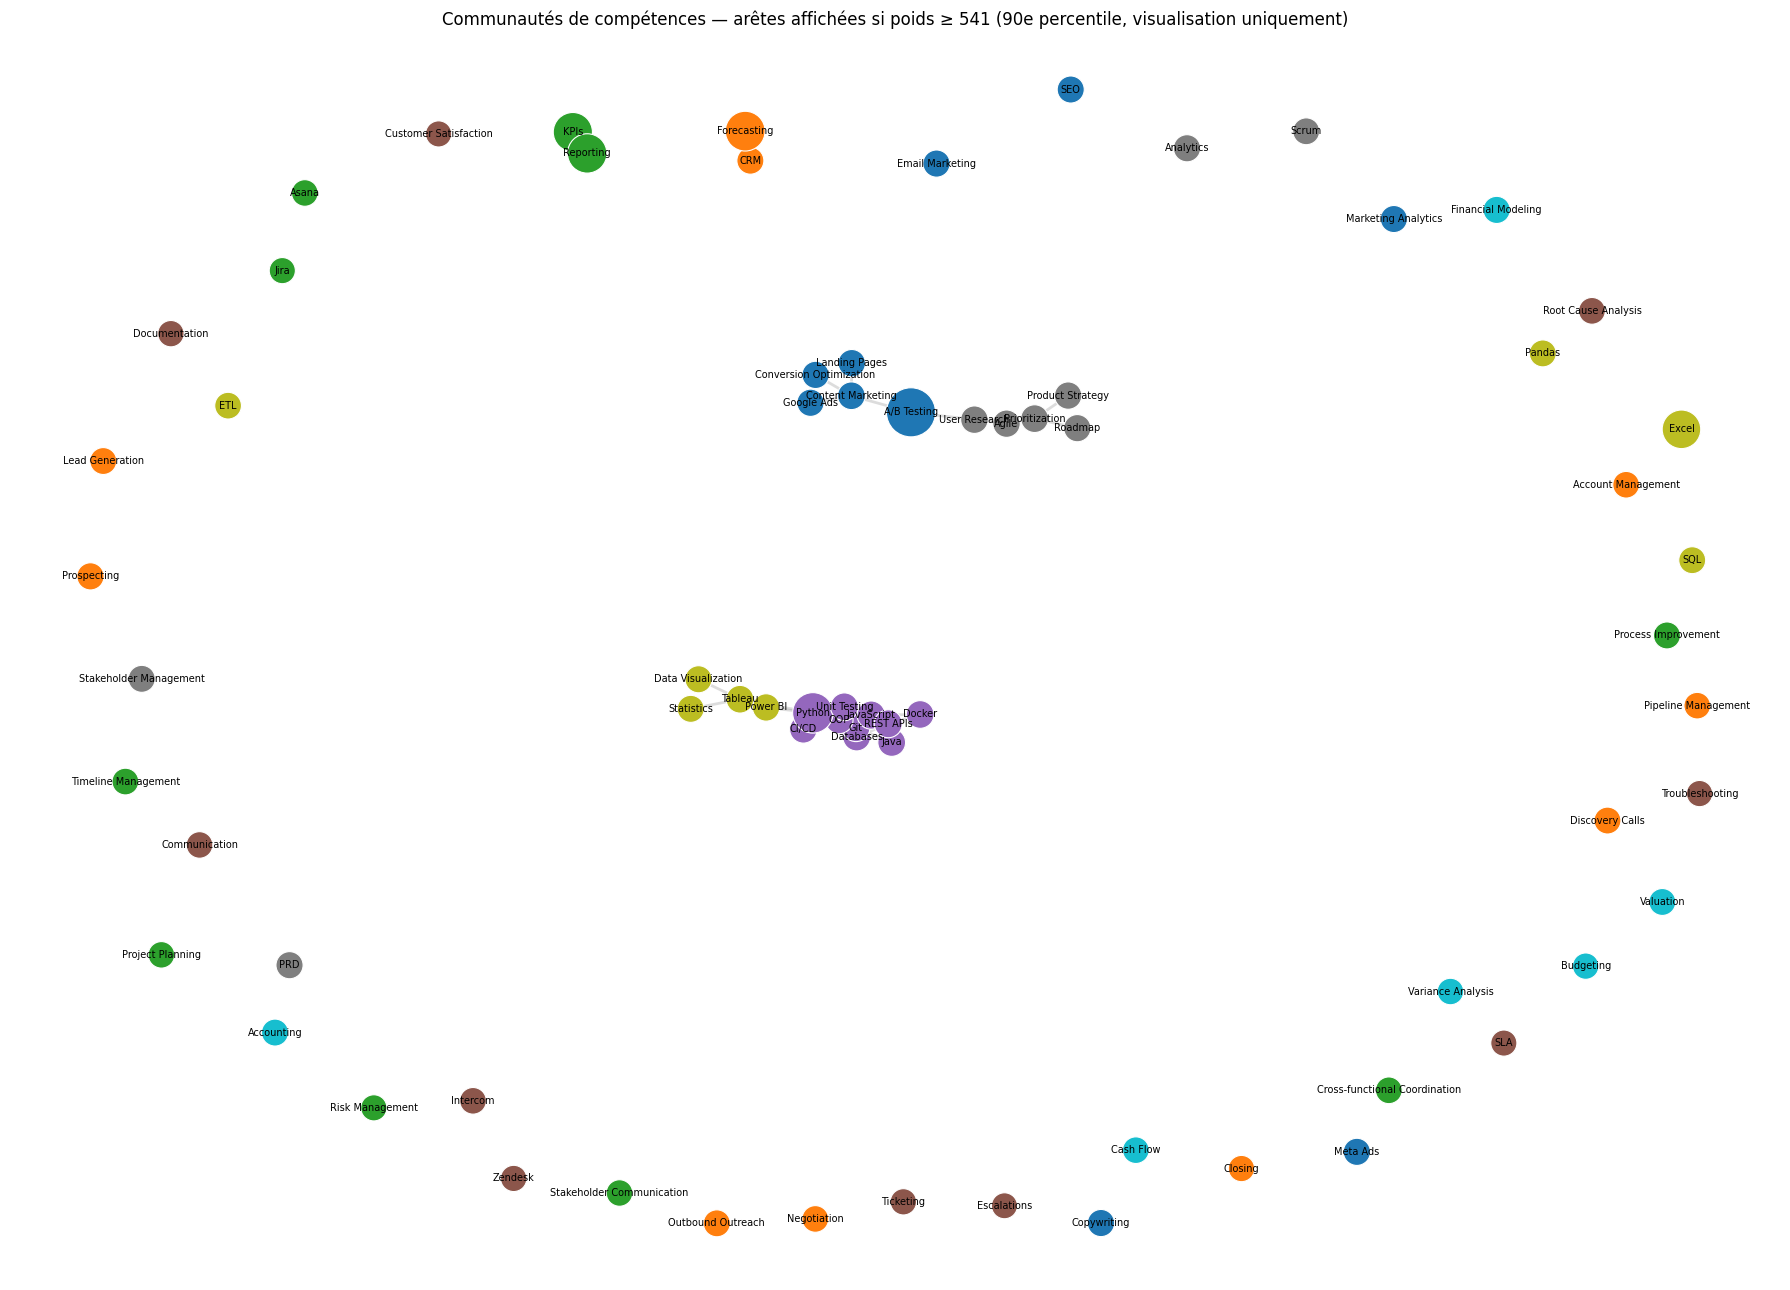

Arêtes analytiques : 359
Arêtes affichées : 39


In [8]:
visual_threshold = float(edge_weights.quantile(0.90))
G_visual = nx.Graph()
G_visual.add_nodes_from(G_skills.nodes())
G_visual.add_edges_from(
    (u, v, data)
    for u, v, data in G_skills.edges(data=True)
    if data["weight"] >= visual_threshold
)

positions = nx.spring_layout(G_visual, seed=42, weight="weight", k=0.85)
communities_for_color = [skill_community[node] for node in G_visual.nodes()]
strength_values = np.array([
    G_skills.degree(node, weight="weight") for node in G_visual.nodes()
], dtype=float)
node_sizes = 350 + 900 * (strength_values - strength_values.min()) / max(
    strength_values.max() - strength_values.min(), 1
)
visual_weights = [G_visual[u][v]["weight"] for u, v in G_visual.edges()]
max_visual_weight = max(visual_weights, default=1)
edge_widths = [0.4 + 3.0 * weight / max_visual_weight for weight in visual_weights]

fig, ax = plt.subplots(figsize=(18, 13))
nx.draw_networkx_edges(
    G_visual, positions, width=edge_widths, alpha=0.25, edge_color="#777777", ax=ax
)
nx.draw_networkx_nodes(
    G_visual,
    positions,
    node_color=communities_for_color,
    cmap=plt.get_cmap("tab10"),
    node_size=node_sizes,
    edgecolors="white",
    linewidths=0.8,
    ax=ax,
)
nx.draw_networkx_labels(G_visual, positions, font_size=7, ax=ax)
ax.set_title(
    f"Communautés de compétences — arêtes affichées si poids ≥ {visual_threshold:.0f} "
    "(90e percentile, visualisation uniquement)"
)
ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "skill_communities.png", dpi=180, bbox_inches="tight")
plt.show()

print("Arêtes analytiques :", G_skills.number_of_edges())
print("Arêtes affichées :", G_visual.number_of_edges())

## 10. Projection des communautés globales de skills sur chaque CV

Le graphe précédent fournit une correspondance `skill → communauté`. Pour chaque CV, nous prenons
ses compétences, remplaçons chacune par son identifiant communautaire et comptons les occurrences.
Par exemple, trois skills de la communauté 0 et deux de la communauté 1 donnent les proportions
$3/5$ et $2/5$. Cette distribution transforme une structure globale entre compétences en features
internes propres à chaque CV.

## 11. Features de concentration et de diversité

Nous calculons : nombre de skills, nombre de communautés représentées, communauté dominante,
effectif dominant et proportion dominante. La **dominant share** vaut

$$\text{dominant share}=\frac{\text{skills dans la communauté dominante}}
{\text{nombre total de skills}}.$$

Une valeur proche de 1 indique une forte concentration dans une famille. L'entropie de Shannon est

$$H=-\sum_c p_c\log(p_c),$$

où $p_c$ est la proportion de skills dans la communauté $c$. Une faible entropie indique une
concentration ; une valeur élevée indique une répartition sur plusieurs groupes. Nous ajoutons une
entropie normalisée $H/\log(C)$ lorsque $C>1$, et 0 pour un seul groupe. Elle facilite la comparaison
entre CV couvrant des nombres de communautés différents. Ces valeurs restent des features : aucun
seuil « spécialisé/polyvalent » n'est défini ici.

In [9]:
def cv_internal_features(resume_id, skills):
    unique_skills = as_unique_list(skills)
    communities = [skill_community[skill] for skill in unique_skills]
    counts = Counter(communities)
    n_skills = len(unique_skills)

    if n_skills == 0:
        return {
            "resume_id": resume_id,
            "n_skills": 0,
            "n_skill_communities": 0,
            "dominant_skill_community": None,
            "dominant_skill_community_count": 0,
            "dominant_skill_community_share": np.nan,
            "skill_community_entropy": 0.0,
            "skill_community_entropy_normalized": 0.0,
        }

    dominant_count = max(counts.values())
    dominant_community = min(
        community for community, count in counts.items() if count == dominant_count
    )
    proportions = [count / n_skills for count in counts.values()]
    entropy = -sum(p * math.log(p) for p in proportions)
    n_communities = len(counts)
    normalized_entropy = entropy / math.log(n_communities) if n_communities > 1 else 0.0

    return {
        "resume_id": resume_id,
        "n_skills": n_skills,
        "n_skill_communities": n_communities,
        "dominant_skill_community": dominant_community,
        "dominant_skill_community_count": dominant_count,
        "dominant_skill_community_share": dominant_count / n_skills,
        "skill_community_entropy": entropy,
        "skill_community_entropy_normalized": normalized_entropy,
    }


cv_feature_rows = [
    cv_internal_features(resume_id, skills)
    for resume_id, skills in zip(df_resumes["resume_id"], df_resumes["skills"])
]
cv_features_df = pd.DataFrame(cv_feature_rows)
cv_features_df.to_csv(
    RESULTS_DIR / "step5_cv_internal_community_features.csv", index=False
)
display(cv_features_df.head())

,resume_id,n_skills,n_skill_communities,dominant_skill_community,dominant_skill_community_count,dominant_skill_community_share,skill_community_entropy,skill_community_entropy_normalized
0,R_000000,7,1,3,7,1.000000,-0.000000,0.000000
1,R_000001,5,1,0,5,1.000000,-0.000000,0.000000
2,R_000002,6,1,3,6,1.000000,-0.000000,0.000000
3,R_000003,6,2,6,5,0.833333,0.450561,0.650022
4,R_000004,5,1,6,5,1.000000,-0.000000,0.000000


## 12. Vérification humaine sur quelques CV

Une moyenne peut cacher des cas différents. Nous sélectionnons, lorsqu'ils existent, un CV limité à
une seule communauté, un CV couvrant le plus de communautés, un CV de dominant share élevée et un
CV d'entropie maximale. Pour chaque cas, nous affichons les compétences et leur mapping afin de
vérifier que les features ont le sens attendu. La sélection est descriptive et n'entraîne aucun
modèle.

In [10]:
feature_index = cv_features_df.set_index("resume_id")
resume_index = df_resumes.set_index("resume_id")

candidate_ids = []
single = cv_features_df[cv_features_df["n_skill_communities"] == 1]
if not single.empty:
    candidate_ids.append(("une seule communauté", single.iloc[0]["resume_id"]))
candidate_ids.extend([
    ("nombre maximal de communautés", cv_features_df.loc[cv_features_df["n_skill_communities"].idxmax(), "resume_id"]),
    ("dominant share maximal", cv_features_df.loc[cv_features_df["dominant_skill_community_share"].idxmax(), "resume_id"]),
    ("entropie maximale", cv_features_df.loc[cv_features_df["skill_community_entropy"].idxmax(), "resume_id"]),
])

seen = set()
example_rows = []
for reason, resume_id in candidate_ids:
    if resume_id in seen:
        continue
    seen.add(resume_id)
    resume = resume_index.loc[resume_id]
    skills = as_unique_list(resume["skills"])
    features = feature_index.loc[resume_id]
    example_rows.append({
        "cas": reason,
        "resume_id": resume_id,
        "role": resume.get("role"),
        "seniority": resume.get("seniority"),
        "skills": skills,
        "skill_communities": [skill_community[skill] for skill in skills],
        "n_skill_communities": int(features["n_skill_communities"]),
        "dominant_share": float(features["dominant_skill_community_share"]),
        "entropy": float(features["skill_community_entropy"]),
    })

display(pd.DataFrame(example_rows))

,cas,resume_id,role,seniority,skills,skill_communities,n_skill_communities,dominant_share,entropy
0,une seule communauté,R_000000,Software Engineer,Senior,"[OOP, Databases, Git, Docker, Python, Unit Tes...","[3, 3, 3, 3, 3, 3, 3]",1,1.000000,-0.000000
1,nombre maximal de communautés,R_000005,Financial Analyst,Mid,"[Forecasting, KPIs, Valuation, Reporting, Vari...","[1, 2, 7, 2, 7, 6, 7]",4,0.428571,1.277034
2,entropie maximale,R_000050,Junior Accountant,Junior,"[Cash Flow, Forecasting, Excel, KPIs, Reporting]","[7, 1, 6, 2, 2]",4,0.400000,1.332179


## 13. Distribution des features internes des CV

Les distributions montrent le comportement de l'ensemble des 10 000 CV sans réduire les profils à
une seule moyenne. Nous utilisons des barres pour le nombre discret de communautés et des
histogrammes pour la proportion dominante et l'entropie. Nous décrivons ce qui est observé sans
choisir de seuil de classification.

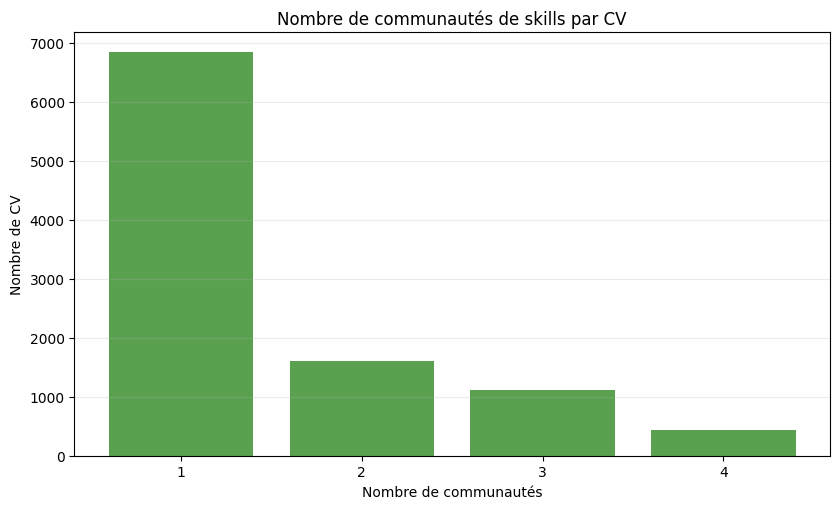

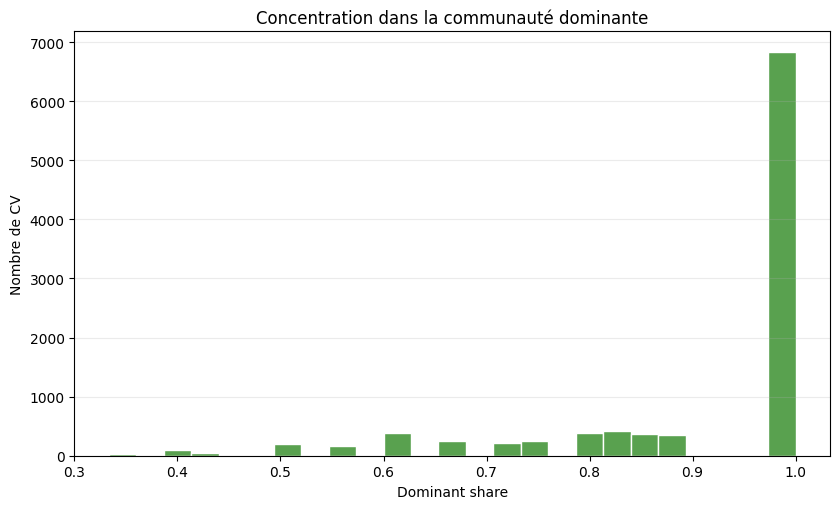

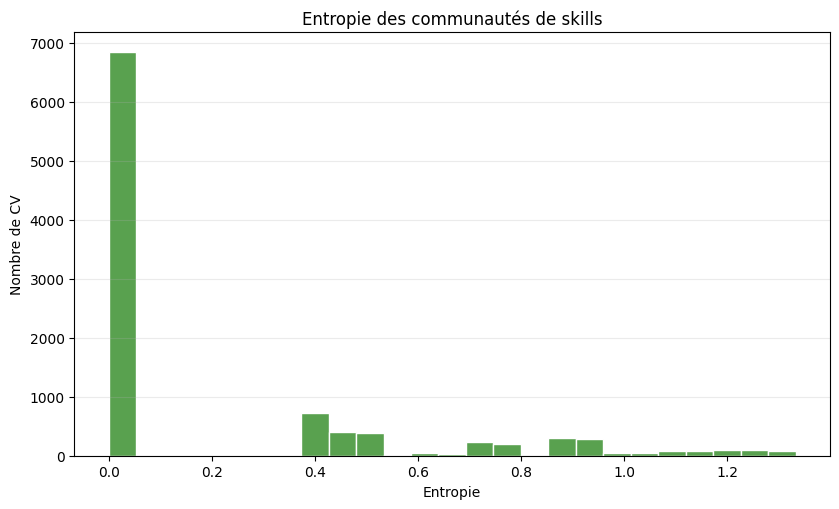

,n_skills,n_skill_communities,dominant_skill_community_share,skill_community_entropy,skill_community_entropy_normalized
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.488800,1.515400,0.912444,0.221173,0.229418
std,1.120893,0.858741,0.150503,0.364255,0.344577
min,5.000000,1.000000,0.333333,-0.000000,0.000000
25%,5.000000,1.000000,0.857143,-0.000000,0.000000
50%,6.000000,1.000000,1.000000,-0.000000,0.000000
75%,7.000000,2.000000,1.000000,0.410116,0.591673
max,8.000000,4.000000,1.000000,1.332179,0.970951


In [11]:
distribution_specs = [
    ("n_skill_communities", "Nombre de communautés de skills par CV", "Nombre de communautés", "cv_n_skill_communities.png", True),
    ("dominant_skill_community_share", "Concentration dans la communauté dominante", "Dominant share", "cv_dominant_skill_community_share.png", False),
    ("skill_community_entropy", "Entropie des communautés de skills", "Entropie", "cv_skill_community_entropy.png", False),
]

for column, title, xlabel, filename, discrete in distribution_specs:
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    values = cv_features_df[column].dropna()
    if discrete:
        counts = values.value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color="#59A14F")
    else:
        ax.hist(values, bins=25, color="#59A14F", edgecolor="white")
    ax.set(title=title, xlabel=xlabel, ylabel="Nombre de CV")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=170, bbox_inches="tight")
    plt.show()

feature_stats = {
    column: {
        key: float(value)
        for key, value in cv_features_df[column].describe().to_dict().items()
    }
    for column in [
        "n_skills",
        "n_skill_communities",
        "dominant_skill_community_share",
        "skill_community_entropy",
        "skill_community_entropy_normalized",
    ]
}
display(cv_features_df[[
    "n_skills", "n_skill_communities", "dominant_skill_community_share",
    "skill_community_entropy", "skill_community_entropy_normalized"
]].describe())

## 14. Assertions et sauvegardes reproductibles

Les assertions vérifient la couverture des 73 compétences, la positivité des poids, l'unicité de
l'affectation communautaire et la validité des 10 000 lignes de features. Le graphe complet est
sauvegardé en pickle pour conserver les poids. Le JSON mémorise aussi tous les runs, le seuil utilisé
uniquement pour la figure et les statistiques des features.

In [12]:
assert G_skills.number_of_nodes() == 73
assert all(data.get("weight", 0) > 0 for _, _, data in G_skills.edges(data=True))
assert set(skill_community) == set(all_skills)
assert len(skill_community) == len(all_skills)
assert len(cv_features_df) == 10_000
assert cv_features_df["resume_id"].is_unique

with_skills = cv_features_df["n_skills"] > 0
assert (cv_features_df.loc[with_skills, "n_skill_communities"] >= 1).all()
assert cv_features_df.loc[with_skills, "dominant_skill_community_share"].between(
    0, 1, inclusive="right"
).all()
assert (cv_features_df["skill_community_entropy"] >= -1e-12).all()

with (PROCESSED_DIR / "skill_graph.pkl").open("wb") as file:
    pickle.dump(G_skills, file, protocol=pickle.HIGHEST_PROTOCOL)

community_sizes = [len(community) for community in best_communities]
summary = {
    "dataset_id": DATASET_ID,
    "n_resumes": int(len(df_resumes)),
    "n_skill_nodes": int(n_skill_nodes),
    "n_skill_edges": int(n_skill_edges),
    "density": float(skill_density),
    "n_connected_components": int(n_connected_components),
    "n_isolates": int(n_isolates),
    "average_degree": average_degree,
    "average_strength": average_strength,
    "edge_weight_statistics": weight_stats,
    "graph_is_nearly_complete": bool(skill_density >= 0.90),
    "missing_possible_edges": int(missing_edges),
    "seeds_tested": SEEDS,
    "max_iter": MAX_ITER,
    "runs": run_rows,
    "selected_seed": best_seed,
    "selection_reason": "highest weighted modularity among tested seeds",
    "selected_weighted_modularity": best_modularity,
    "n_skill_communities": len(best_communities),
    "skill_community_sizes": community_sizes,
    "visualization_only_weight_threshold": visual_threshold,
    "visualization_only_quantile": 0.90,
    "cv_internal_feature_statistics": feature_stats,
    "assertions_passed": True,
    "scope_confirmation": "No classification, link prediction, embeddings, or CV-Job graph reconstruction performed.",
}
(RESULTS_DIR / "step5_skill_graph_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8"
)

print("Toutes les assertions sont passées.")
print("Graphe :", PROCESSED_DIR / "skill_graph.pkl")
print("Résumé :", RESULTS_DIR / "step5_skill_graph_summary.json")

Toutes les assertions sont passées.
Graphe : data\processed\skill_graph.pkl
Résumé : results\step5_skill_graph_summary.json


## Interprétation et conclusion

- Le graphe complet contient **73 compétences et 359 arêtes**, pour une densité de **0,1366**. Il
  est donc relativement sparse et très loin d'un graphe complet : aucun seuil analytique n'est
  nécessaire. Il possède deux composantes connexes et aucun isolé. La seconde composante regroupe
  les dix compétences de support client ; elle ne cooccurre jamais avec les autres familles dans
  les CV synthétiques.
- Les poids vont de **458 à 1 021 CV**, avec une médiane de **512** et une moyenne de **513,54**.
  La paire `KPIs–Reporting` domine nettement avec 1 021 cooccurrences. Elle est suivie notamment de
  `JavaScript–Python` (562), `JavaScript–REST APIs` (561), `OOP–Python` (557) et
  `Python–Tableau` (556). La faible dispersion de la plupart des autres poids reflète la génération
  très régulière du dataset synthétique.
- Les seeds 0 et 3–4 trouvent **8 communautés**, tandis que les seeds 1–2 fusionnent deux groupes et
  n'en trouvent que **7**. Toutes convergent en 3 ou 4 itérations. Les modularités pondérées vont de
  **0,7007 à 0,7184**. La seed **3** est retenue : elle atteint la modularité maximale `0,718392`, à
  égalité avec la seed 4, et `idxmax` sélectionne reproductiblement la première occurrence.
- Les huit communautés retenues comptent entre **6 et 10 skills** et sont lisibles à partir de leurs
  membres : Marketing digital ; Sales/CRM ; Project/Operations ; Software Engineering ; Support
  client ; Product Management ; Data/BI ; Finance/Accounting. Ces noms sont une interprétation
  descriptive des compétences listées, pas une annotation produite par un LLM.
- Un CV possède en moyenne **6,49 skills** et couvre **1,52 communauté**. La médiane du nombre de
  communautés vaut 1 : **6 841 CV (68,41 %)** restent entièrement dans une seule famille. Les autres
  couvrent deux (1 607 CV), trois (1 109) ou quatre communautés (443).
- La dominant share moyenne vaut **0,9124**, avec une médiane de 1 et un minimum de 0,3333.
  L'entropie moyenne vaut **0,2212**, sa médiane est nulle et son maximum vaut **1,3322**. Le dataset
  contient donc beaucoup de CV très concentrés, mais aussi une minorité de profils plus diversifiés.
  Ces features peuvent être utiles plus tard pour étudier spécialisé/polyvalent, mais aucun seuil ni
  label n'est défini à cette étape.
- Limites : les cooccurrences décrivent les régularités du générateur synthétique et non un marché
  du travail réel ; elles ne prouvent aucune proximité sémantique ou causalité. Une compétence
  transversale peut aussi relier plusieurs familles. Enfin, le seuil `poids ≥ 541` (90e percentile)
  est utilisé **uniquement pour la figure** : les communautés et toutes les métriques reposent sur
  les 359 arêtes du graphe complet.

Cette étape ne réalise ni classification, ni link prediction, ni embeddings, et ne reconstruit pas
le graphe biparti CV–Job.